In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


d:\GP\Notebooks\Scimilarity\Scimilarity-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_healthy1 = sc.read_h5ad(r"d:\GP\Datasets\10k_pbmcs_proc.h5ad")
print(adata_healthy1)
adata_diseased1 = sc.read_10x_h5(r"C:\Users\loq\Downloads\10k_3p_Human_diseased_PBMC_Myelofibrosis_Fix_count_filtered_feature_bc_matrix.h5")
print(adata_diseased1)


AnnData object with n_obs × n_vars = 11990 × 12000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_types', 'hvg'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'
AnnData object with n_obs × n_vars = 11538 × 38606
    var: 'gene_ids', 'feature_types', 'genome'


d:\GP\Notebooks\Scimilarity\Scimilarity-venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
adata_healthy1.var.head()

,gene_symbols,n_counts-0,n_counts-1,n_counts,highly_variable,highly_variable_rank,means,variances,variances_norm
SAMD11,SAMD11,7.0,4.0,11.0,True,8398.0,0.000917,0.000917,0.937632
PLEKHN1,PLEKHN1,30.0,10.0,39.0,True,7424.0,0.003253,0.003409,0.945401
HES4,HES4,580.0,294.0,855.0,True,189.0,0.071309,0.200353,2.573027
ISG15,ISG15,4014.0,1888.0,5705.0,True,269.0,0.475813,1.413837,2.089724
AGRN,AGRN,36.0,8.0,41.0,True,7906.0,0.003420,0.003575,0.941332


In [4]:
adata_diseased1.var.head()

,gene_ids,feature_types,genome
DDX11L2,ENSG00000290825,Gene Expression,GRCh38
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38


In [5]:
adata_diseased1.obs.head()

""
AAACCATTCAGCAGAG-1
AAACCCGCAAGGTCAT-1
AAACCCGCAATCGAAC-1
AAACCCGCACAGGATT-1
AAACCCGCATCCGTTA-1


In [6]:
# add disease column in healthy data but fill with "Healthy"
adata_healthy1.obs["disease"] = "normal"
# add disease column in diseased data and fill with "Diseased"
adata_diseased1.obs["disease"] = "diseased"

In [7]:
print(adata_healthy1.obs.head())
print(adata_diseased1.obs.head())

                    n_counts  batch  labels       str_labels        cell_type  \
AAACCTGAGCTAGTGG-1    4520.0      0       2      CD4 T cells      CD4 T cells   
AAACCTGCACATTAGC-1    2788.0      0       2      CD4 T cells      CD4 T cells   
AAACCTGCACTGTTAG-1    4667.0      0       1  CD14+ Monocytes  CD14+ Monocytes   
AAACCTGCATAGTAAG-1    4440.0      0       1  CD14+ Monocytes  CD14+ Monocytes   
AAACCTGCATGAACCT-1    3224.0      0       3      CD8 T cells      CD8 T cells   

                   disease  
AAACCTGAGCTAGTGG-1  normal  
AAACCTGCACATTAGC-1  normal  
AAACCTGCACTGTTAG-1  normal  
AAACCTGCATAGTAAG-1  normal  
AAACCTGCATGAACCT-1  normal  
                     disease
AAACCATTCAGCAGAG-1  diseased
AAACCCGCAAGGTCAT-1  diseased
AAACCCGCAATCGAAC-1  diseased
AAACCCGCACAGGATT-1  diseased
AAACCCGCATCCGTTA-1  diseased


In [8]:
import scanpy as sc
import numpy as np

# make gene names consistent
adata_healthy1.var_names_make_unique()
adata_diseased1.var_names_make_unique()

# uppercase gene names
adata_healthy1.var_names = adata_healthy1.var_names.str.upper()
adata_diseased1.var_names = adata_diseased1.var_names.str.upper()

# find shared genes
common_genes = adata_healthy1.var_names.intersection(adata_diseased1.var_names)

print(f"Healthy genes: {adata_healthy1.n_vars}")
print(f"Diseased genes: {adata_diseased1.n_vars}")
print(f"Common genes: {len(common_genes)}")

# subset
adata_healthy = adata_healthy1[:, common_genes].copy()
adata_diseased = adata_diseased1[:, common_genes].copy()

# enforce identical gene order
adata_diseased = adata_diseased[:, adata_healthy.var_names]

# clean metadata types
for col in ["cell_type", "batch", "donor"]:
    if col in adata_healthy.obs.columns:
        adata_healthy.obs[col] = adata_healthy.obs[col].astype(str)
    if col in adata_diseased.obs.columns:
        adata_diseased.obs[col] = adata_diseased.obs[col].astype(str)

# concatenate
adata_combined = sc.concat(
    [adata_healthy, adata_diseased],
    join="inner",
    label="dataset",
    keys=["10k_PBMCs", "Primary_Myelofibrosis_PBMCs"],
    index_unique="-"
)

print(adata_combined)

# ensure numeric matrix
if adata_combined.X.dtype == np.dtype("O"):
    adata_combined.X = adata_combined.X.astype(np.float32)

# save
adata_combined.write("combined_PBMCs_healthy_diseased.h5ad")

print("Saved as combined_PBMCs_healthy_diseased.h5ad")

Healthy genes: 12000
Diseased genes: 38606
Common genes: 11895
AnnData object with n_obs × n_vars = 23528 × 11895
    obs: 'disease', 'dataset'
Saved as combined_PBMCs_healthy_diseased.h5ad


In [9]:
# downsample adata to 15k cells for faster processing and keep same proportion of healthy/diseased and cell types
adata = adata_combined.obs.groupby('disease', group_keys=False).apply(lambda x: x.sample(int(15000 * len(x) / len(adata_combined)), random_state=42))
adata = adata.sort_index()
adata= adata_combined[adata.index]
print(adata.shape)

(14999, 11895)


C:\Users\loq\AppData\Local\Temp\ipykernel_3856\1152652543.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata = adata_combined.obs.groupby('disease', group_keys=False).apply(lambda x: x.sample(int(15000 * len(x) / len(adata_combined)), random_state=42))
C:\Users\loq\AppData\Local\Temp\ipykernel_3856\1152652543.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adata = adata_combined.obs.groupby('disease', group_keys=False).apply(lambda x: x.sample(int(15000 * len(x) / len(adata_combined)), random_state=42)

In [10]:
print(adata_healthy1.X.max(), adata_diseased1.X.max())

8029.0 9383.0


In [11]:
print(adata_healthy1.X[:50, :50])
print(adata_diseased1.X[:50, :50])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 121 stored elements and shape (50, 50)>
  Coords	Values
  (0, 3)	1.0
  (0, 8)	4.0
  (0, 27)	1.0
  (0, 32)	1.0
  (1, 9)	1.0
  (1, 40)	1.0
  (3, 9)	1.0
  (3, 28)	2.0
  (5, 46)	2.0
  (6, 2)	2.0
  (6, 3)	3.0
  (6, 9)	1.0
  (6, 22)	1.0
  (6, 46)	2.0
  (7, 9)	1.0
  (7, 14)	1.0
  (7, 26)	1.0
  (8, 49)	2.0
  (9, 9)	2.0
  (9, 27)	1.0
  (9, 28)	1.0
  (9, 49)	1.0
  (10, 9)	1.0
  (10, 40)	1.0
  (11, 24)	1.0
  :	:
  (37, 49)	1.0
  (38, 3)	2.0
  (39, 3)	1.0
  (39, 14)	1.0
  (39, 31)	1.0
  (40, 28)	1.0
  (42, 27)	1.0
  (42, 32)	1.0
  (43, 3)	1.0
  (43, 8)	1.0
  (43, 24)	1.0
  (43, 35)	1.0
  (43, 40)	1.0
  (44, 3)	3.0
  (44, 12)	1.0
  (45, 7)	1.0
  (46, 28)	1.0
  (46, 39)	1.0
  (46, 43)	1.0
  (47, 3)	1.0
  (48, 24)	1.0
  (49, 3)	2.0
  (49, 24)	1.0
  (49, 25)	1.0
  (49, 28)	1.0
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 50 stored elements and shape (50, 50)>
  Coords	Values
  (0, 18)	2.0
  (3, 16)	1.0
  (3, 30)	1.0
  (3, 3

In [12]:
adata.var.head()

""
SAMD11
PLEKHN1
HES4
ISG15
AGRN


In [13]:
print(adata.obs.tail())

                             disease    dataset
TTTGTCATCATGTCCC-1-10k_PBMCs  normal  10k_PBMCs
TTTGTCATCCCAAGAT-1-10k_PBMCs  normal  10k_PBMCs
TTTGTCATCCGATATG-1-10k_PBMCs  normal  10k_PBMCs
TTTGTCATCGTCTGAA-1-10k_PBMCs  normal  10k_PBMCs
TTTGTCATCTGCTTGC-1-10k_PBMCs  normal  10k_PBMCs


In [14]:
print(adata.obs.head())

                                                 disease  \
AAACCAAAGGTCACGT-2-Primary_Myelofibrosis_PBMCs  diseased   
AAACCAAAGTGCGCCA-2-Primary_Myelofibrosis_PBMCs  diseased   
AAACCATTCAGCAGAG-1-Primary_Myelofibrosis_PBMCs  diseased   
AAACCCGCAATCGAAC-1-Primary_Myelofibrosis_PBMCs  diseased   
AAACCCGCACAGGATT-1-Primary_Myelofibrosis_PBMCs  diseased   

                                                                    dataset  
AAACCAAAGGTCACGT-2-Primary_Myelofibrosis_PBMCs  Primary_Myelofibrosis_PBMCs  
AAACCAAAGTGCGCCA-2-Primary_Myelofibrosis_PBMCs  Primary_Myelofibrosis_PBMCs  
AAACCATTCAGCAGAG-1-Primary_Myelofibrosis_PBMCs  Primary_Myelofibrosis_PBMCs  
AAACCCGCAATCGAAC-1-Primary_Myelofibrosis_PBMCs  Primary_Myelofibrosis_PBMCs  
AAACCCGCACAGGATT-1-Primary_Myelofibrosis_PBMCs  Primary_Myelofibrosis_PBMCs  


In [15]:
print(adata)

View of AnnData object with n_obs × n_vars = 14999 × 11895
    obs: 'disease', 'dataset'


In [16]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [17]:
adata.layers["counts"] = adata.X.copy()


C:\Users\loq\AppData\Local\Temp\ipykernel_3856\1570644132.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [18]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=6000,
    flavor="seurat_v3",
    layer="counts",
    subset=True,
    batch_key="dataset",  # Change depending on the batch key for your dataset
)

In [19]:
# add counts layer to adata and lognorm it
from scimilarity.utils import align_dataset, lognorm_counts
adata = align_dataset(adata, ce.gene_order)
adata = lognorm_counts(adata)

d:\GP\Notebooks\Scimilarity\Scimilarity-venv\Lib\site-packages\scimilarity\utils.py:121: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  shell = anndata.concat(


In [20]:
X = adata.X 
embeddings = ce.get_embeddings(X)
print(embeddings.shape)

(14999, 128)


In [21]:
print(type(X))
print(X.dtype)

<class 'scipy.sparse._csr.csr_matrix'>
float64


In [22]:
# save embeddings in obsm
adata.obsm["X_emb"] = embeddings
print(adata.obsm["X_emb"].shape)

(14999, 128)


In [23]:

adata.obs["dataset"] = adata.obs["dataset"].astype(str)

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):
    
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]  
    
    
    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)
  

    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)
   
    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }
    
    return scores

In [25]:
label_keys = ["dataset"]
# Compute scores
scores = compute_silhouette_and_lisi(adata, label_keys, embed_key="X_emb", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'dataset': 0.08851561695337296}
LISI Scores: {'dataset': 1.0}


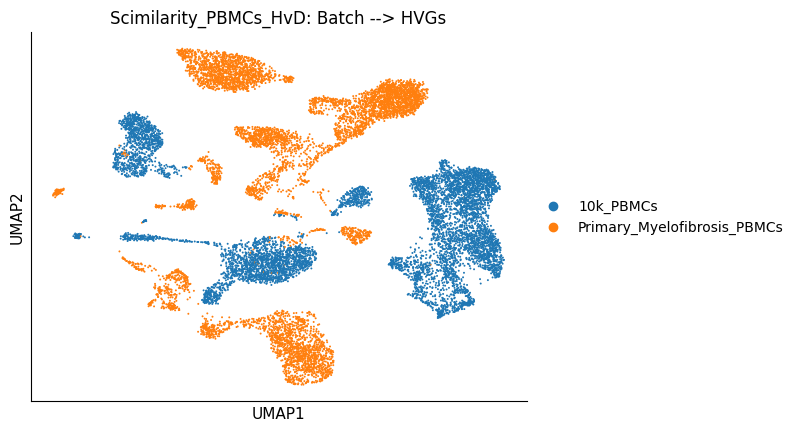

In [26]:
import scanpy as sc

sc.pp.neighbors(adata, use_rep='X_emb')
sc.tl.umap(adata)

# Plot UMAPs
sc.pl.umap(
    adata,
    color=label_keys,
    frameon=True,  # keep axes active
    wspace=0.4,
    title=[
       "Scimilarity_PBMCs_HvD: Batch --> HVGs",
    ],
    show=False,  # we’ll control the display manually
    ncols=1
)

# Grab the axes
axes = plt.gcf().axes  # get all axes from current figure

# Customize axes
for ax in axes:
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)
    ax.set_facecolor("white")             # white background
    ax.spines['left'].set_visible(True)   # show left spine
    ax.spines['bottom'].set_visible(True) # show bottom spine
    ax.spines['top'].set_visible(False)   # hide top spine
    ax.spines['right'].set_visible(False) # hide right spine
    ax.spines['left'].set_color("black")
    ax.spines['bottom'].set_color("black")
    ax.tick_params(axis='both', labelsize=9, colors='black')

# Show the plot
plt.show()

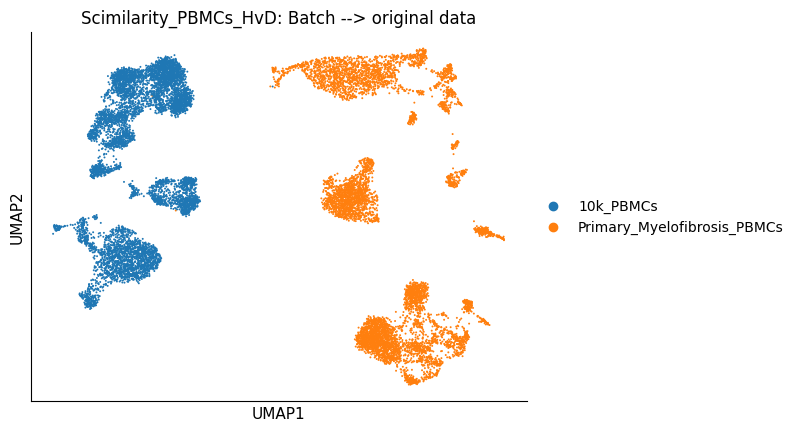

In [27]:
import scanpy as sc

sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Plot UMAPs
sc.pl.umap(
    adata,
    color=label_keys,
    frameon=True,  # keep axes active
    wspace=0.4,
    title=[
       "Scimilarity_PBMCs_HvD: Batch --> original data",
    ],
    show=False,  # we’ll control the display manually
    ncols=1
)

# Grab the axes
axes = plt.gcf().axes  # get all axes from current figure

# Customize axes
for ax in axes:
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)
    ax.set_facecolor("white")             # white background
    ax.spines['left'].set_visible(True)   # show left spine
    ax.spines['bottom'].set_visible(True) # show bottom spine
    ax.spines['top'].set_visible(False)   # hide top spine
    ax.spines['right'].set_visible(False) # hide right spine
    ax.spines['left'].set_color("black")
    ax.spines['bottom'].set_color("black")
    ax.tick_params(axis='both', labelsize=9, colors='black')

# Show the plot
plt.show()